# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
from wordcloud import WordCloud
from nltk.probability import FreqDist
import community
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO

def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [ ]:
carpeta = 'C:/Users/Desktop/caso_06'
textos_andres = []
textos_mansilla = []
textos_cuesta = []
textos_maza = []
textos_rito = []
textos_ivan = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if 'andres mario espinosa' in archivo_norm:
            textos_andres.append((archivo, contenido))
        elif 'jose mansilla' in archivo_norm:
            textos_mansilla.append((archivo, contenido))
        elif 'cuesta novoa' in archivo_norm:
            textos_cuesta.append((archivo, contenido))
        elif 'rito alejo' in archivo_norm:
            textos_rito.append((archivo, contenido))
        elif 'miguel maza' in archivo_norm:
            textos_maza.append((archivo, contenido))
        elif 'ivan ramirez quintero' in archivo_norm:
            textos_ivan.append((archivo, contenido))
        else:
            textos_otros.append((archivo, contenido))

texto_andres = ' '.join([contenido for _, contenido in textos_andres])
texto_mansilla = ' '.join([contenido for _, contenido in textos_mansilla])
texto_cuesta = ' '.join([contenido for _, contenido in textos_cuesta])
texto_rito = ' '.join([contenido for _, contenido in textos_rito])
texto_maza = ' '.join([contenido for _, contenido in textos_maza])
texto_ivan = ' '.join([contenido for _, contenido in textos_ivan])


print(f"Archivos de andres: {len(textos_andres)}")
print(f"Archivos de mansilla: {len(textos_mansilla)}")
print(f"Archivos de maza: {len(textos_maza)}")
print(f"Archivos de cuesta: {len(textos_cuesta)}")
print(f"Archivos de rito: {len(textos_rito)}")
print(f"Archivos de ivan: {len(textos_ivan)}")
print(f"Otros archivos: {len(textos_otros)}")


Archivos de andres: 2
Archivos de mansilla: 3
Archivos de maza: 4
Archivos de cuesta: 1
Archivos de rito: 2
Archivos de ivan: 6
Otros archivos: 2


In [ ]:
# --- Primera lematización:
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)

textos = {
    'Iván Ramirez Quintero': texto_ivan,
    'Miguel Maza Márquez': texto_maza,
    'José Mansilla': texto_mansilla,
    'José del Carmen Cuesta': texto_cuesta,
    'Andrés Mario Espinosa': texto_andres,
    'Rito Alejo del Rio': texto_rito,}

textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

texto_ivan_lem = textos_lematizados['Iván Ramirez Quintero']
texto_maza_lem = textos_lematizados['Miguel Maza Márquez']
texto_mansilla_lem = textos_lematizados['José Mansilla']
texto_cuesta_lem = textos_lematizados['José del Carmen Cuesta']
texto_andres_lem = textos_lematizados['Andrés Mario Espinosa']
texto_rito_lem = textos_lematizados['Rito Alejo del Rio']


#Eliminar palabras cortas:
texto_ivan_lem = eliminar_palabras_cortas(texto_ivan_lem )
texto_maza_lem = eliminar_palabras_cortas(texto_maza_lem )
texto_mansilla_lem = eliminar_palabras_cortas(texto_mansilla_lem)
texto_cuesta_lem = eliminar_palabras_cortas(texto_cuesta_lem)
texto_andres_lem = eliminar_palabras_cortas(texto_andres_lem)
texto_rito_lem = eliminar_palabras_cortas(texto_rito_lem)

##tokenizar
textos = {
    'Iván Ramirez Quintero': texto_ivan_lem,
    'Miguel Maza Márquez': texto_maza_lem,
    'José Mansilla': texto_mansilla_lem,
    'José del Carmen Cuesta': texto_cuesta_lem,
    'Andrés Mario Espinosa': texto_andres_lem,
    'Rito Alejo del Rio': texto_rito_lem,
}
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens


# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# palabras que NO deben lematizarse
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
#------------------------ reconstruir textos --------------------------------
# Construir textos_lemas sin pasar por archivos
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ['Iván Ramirez Quintero', 'Miguel Maza Márquez' , 'José Mansilla', 'José del Carmen Cuesta','Andrés Mario Espinosa', 'Rito Alejo del Rio']}

#----------------  Aplicar la lematización personalizada ------------------------------
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_06.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)
    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final


In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- Stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ------------------------- Limpiar texto -----------------------------------------
textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# --------------------------- Generar skipgramas ---------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

In [12]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Iván Ramirez Quintero':


,Skipgrama,Frecuencia
0,comandante brigada,111
1,ramirez quintero,110
2,ivan ramirez,103
3,grupo paramilitar,94
4,representante victima,86
5,ministerio publico,77
6,comandante ejercito,77
7,inteligencia informacion,77
8,tarjeta profesional,70
9,inteligencia brigada,69



Top 10 skipgramas en 'Miguel Maza Márquez':


,Skipgrama,Frecuencia
0,union patriotica,148
1,pablo escobar,99
2,grupo paramilitar,85
3,carlos castano,84
4,magdalena medio,63
5,cartel medellin,60
6,miembro union,56
7,miembro patriotica,55
8,fidel castano,55
9,miguel marquez,52



Top 10 skipgramas en 'José Mansilla':


...

,Skipgrama,Frecuencia
0,bernardo garzon,56
1,desaparicion forzar,51
2,alfonso garzon,49
3,gomez hurtar,35
4,bernardo alfonso,32
5,batallon solano,26
6,jose carmen,23
7,ivan ramirez,23
8,universidad nacional,22
9,alvaro gomez,19



Top 10 skipgramas en 'Andrés Mario Espinosa':


,Skipgrama,Frecuencia
0,union patriotica,165
1,miembro union,68
2,miembro patriotica,55
3,grupo paramilitar,54
4,central inteligencia,52
5,puerto boyaca,47
6,division inteligencia,43
7,director inteligencia,42
8,cartel medellin,37
9,magdalena medio,36



Top 10 skipgramas en 'Rito Alejo del Rio':


,Skipgrama,Frecuencia
0,rio sucio,41
1,representante victima,34
2,poblacion civil,34
3,operacion genesis,33
4,margen ley,25
5,grupo paramilitar,25
6,victima acreditar,23
7,batallon guerrilla,22
8,version voluntaria,19
9,comandante brigada,19


# **ANÁLISIS DESCRIPTIVO**

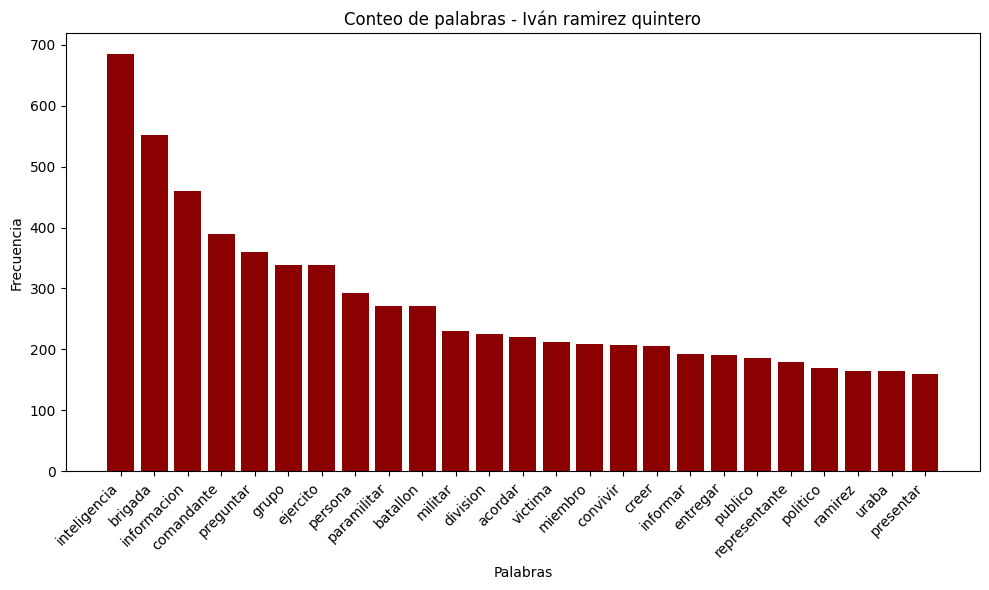

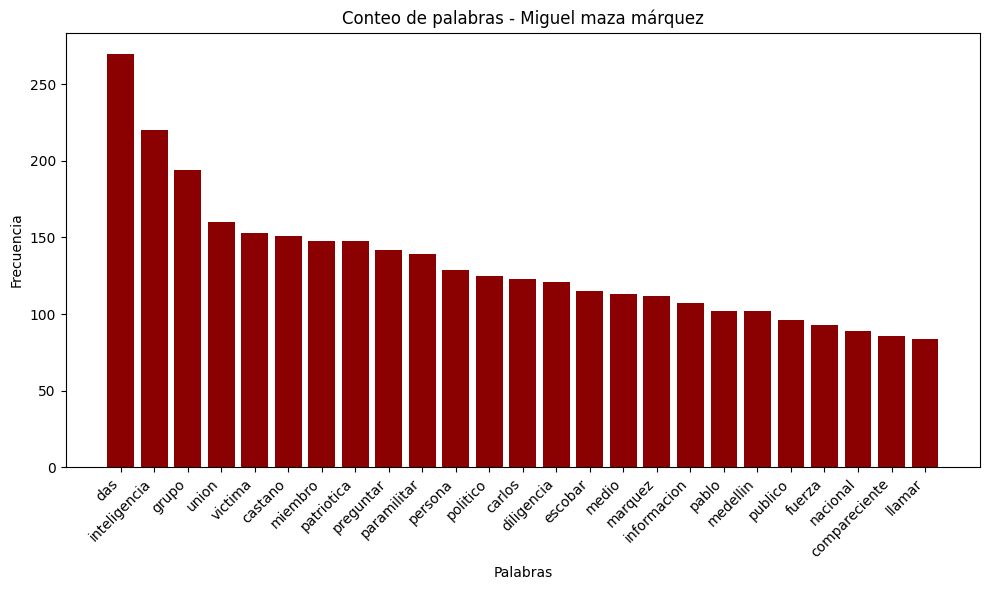

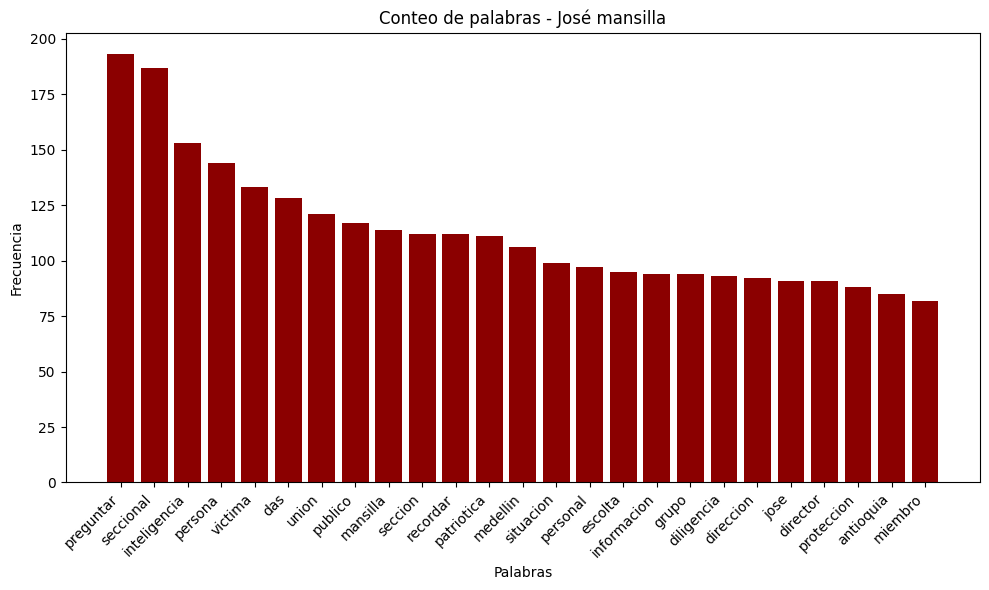

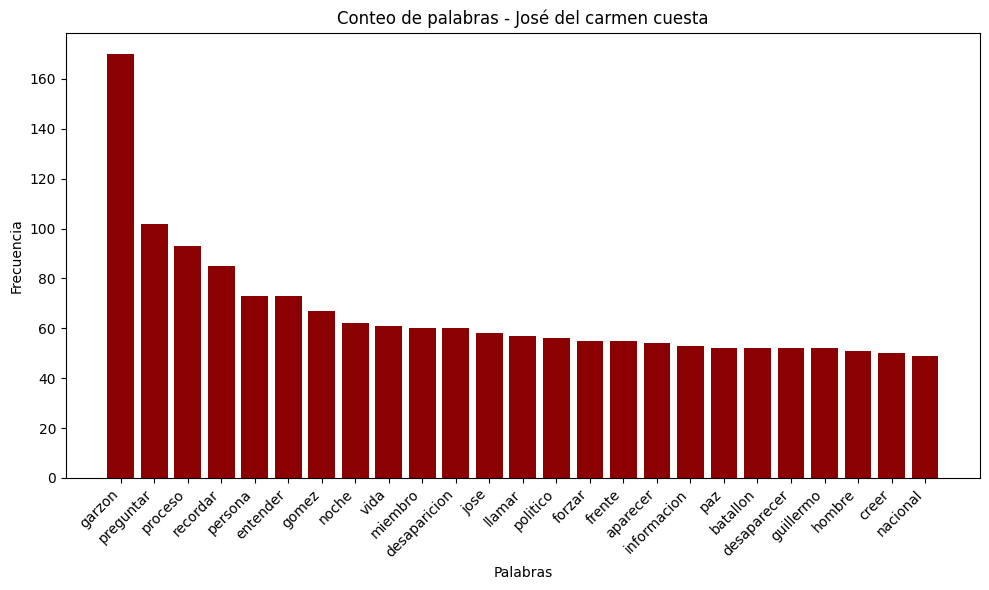

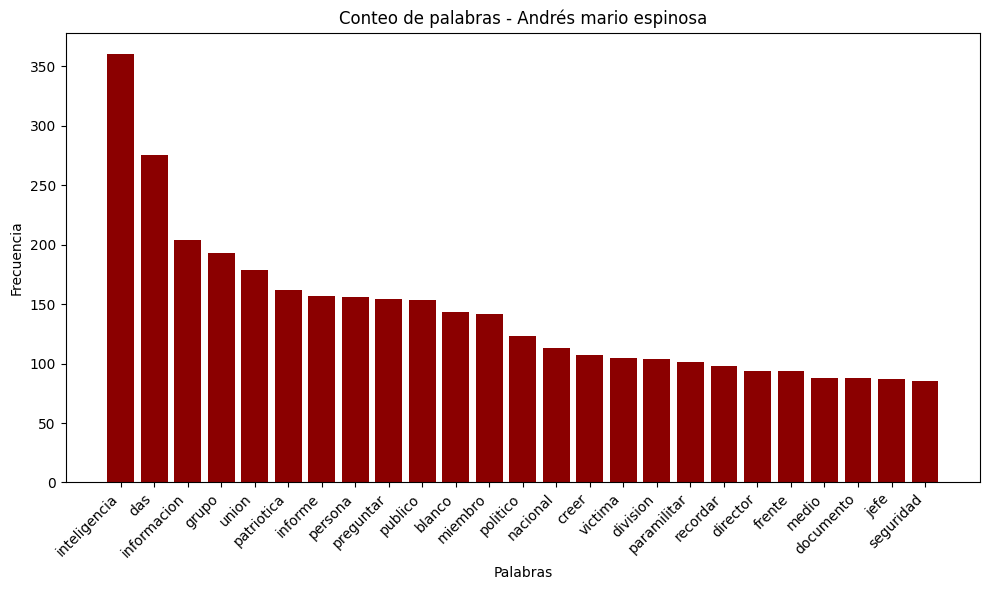

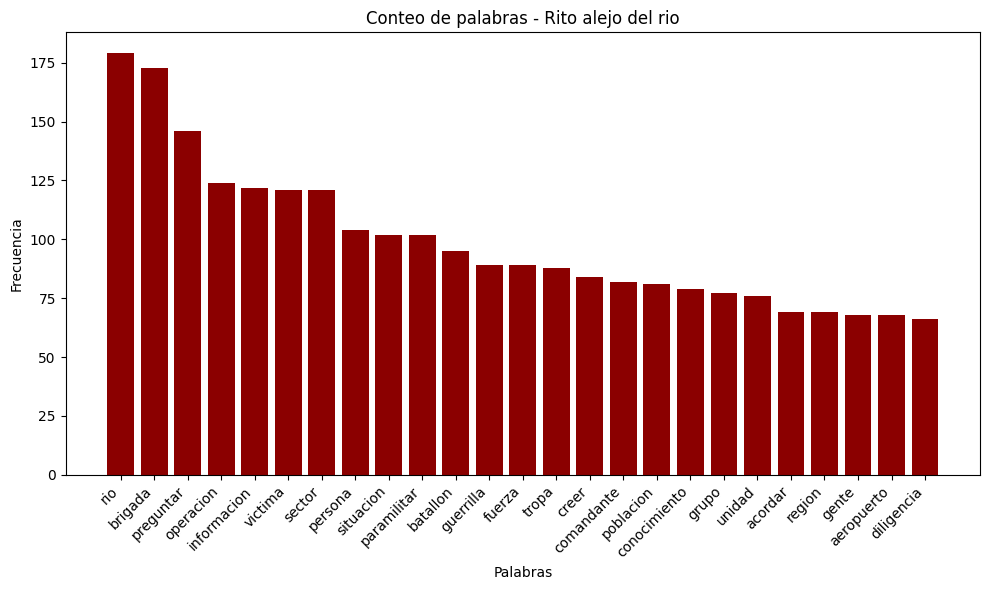

In [10]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [11]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)



 Frecuencias para: Iván Ramirez Quintero
         Palabra  Frecuencia
0   inteligencia         685
1        brigada         551
2    informacion         460
3     comandante         390
4      preguntar         360
5          grupo         339
6       ejercito         338
7        persona         292
8    paramilitar         272
9       batallon         272
10       militar         231
11      division         226
12       acordar         221
13       victima         212
14       miembro         209

 Frecuencias para: Miguel Maza Márquez
         Palabra  Frecuencia
0            das         270
1   inteligencia         220
2          grupo         194
3          union         160
4        victima         153
5        castano         151
6        miembro         148
7     patriotica         148
8      preguntar         142
9    paramilitar         139
10       persona         129
11      politico         125
12        carlos         123
13    diligencia         121
14       escobar   

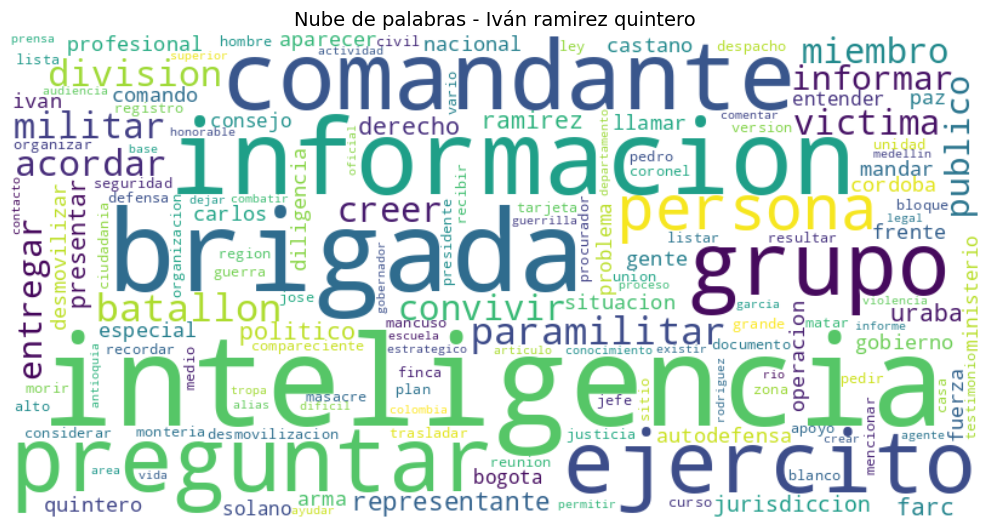

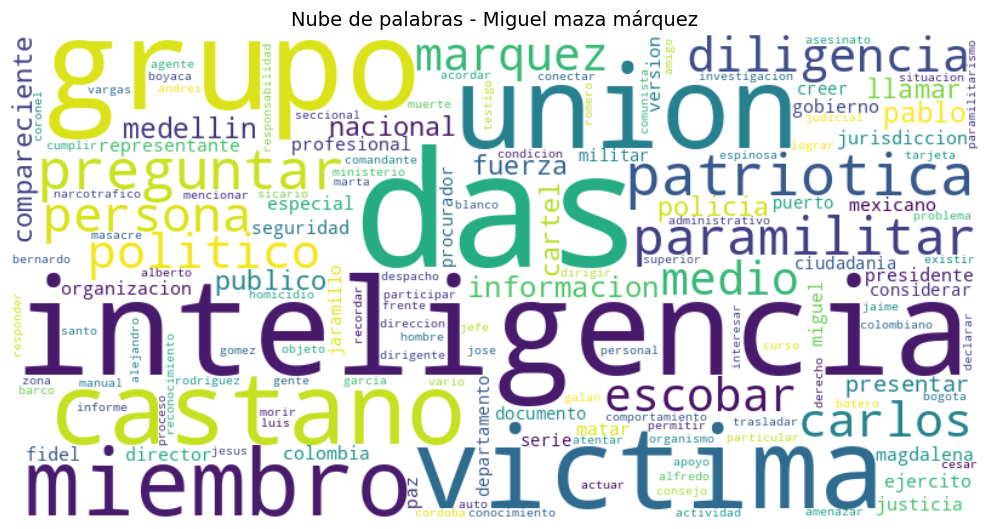

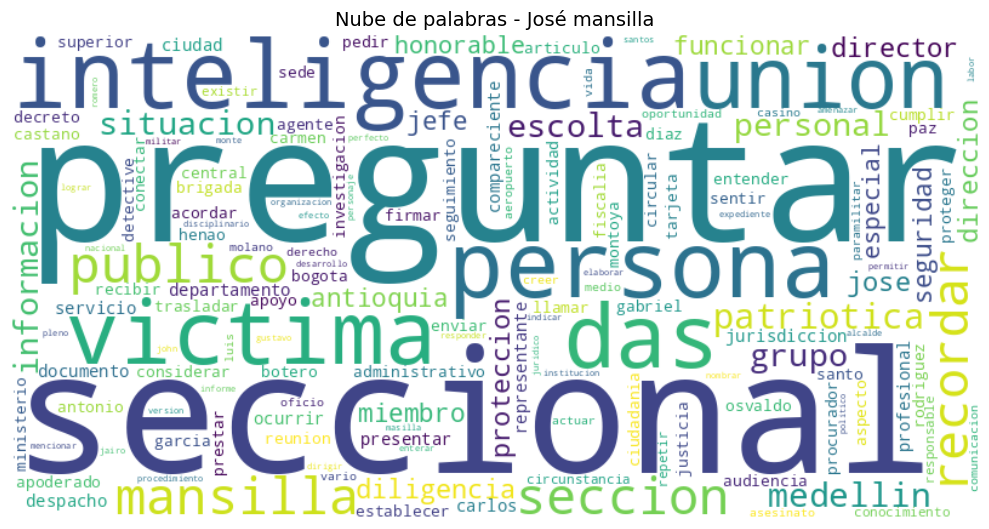

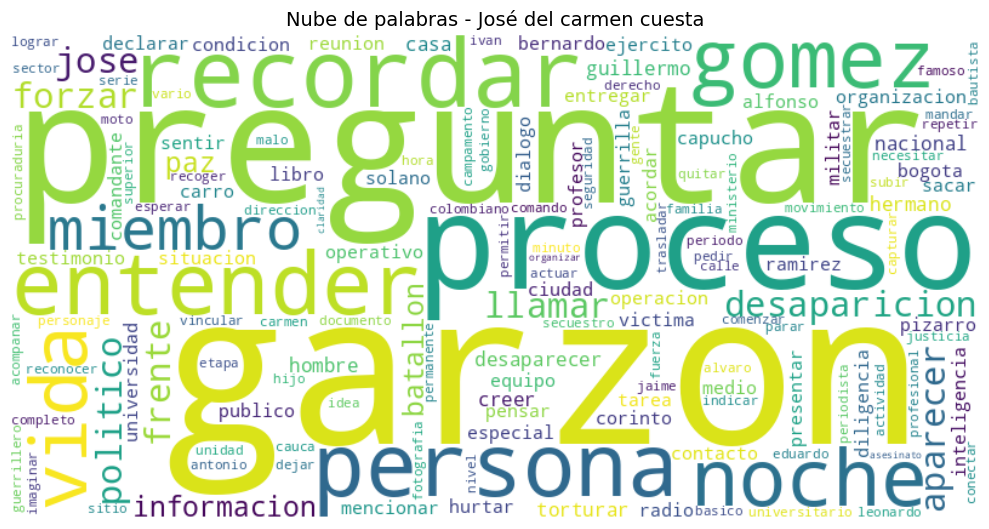

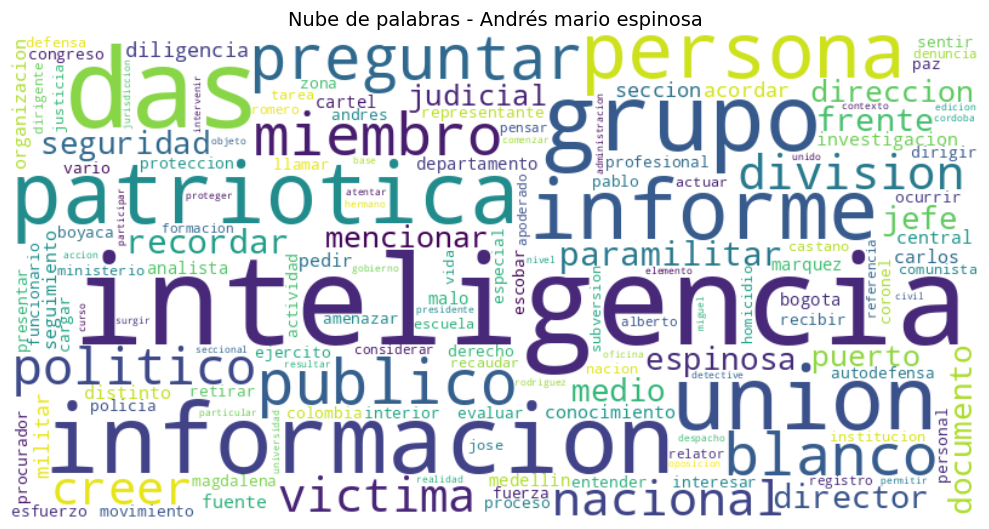

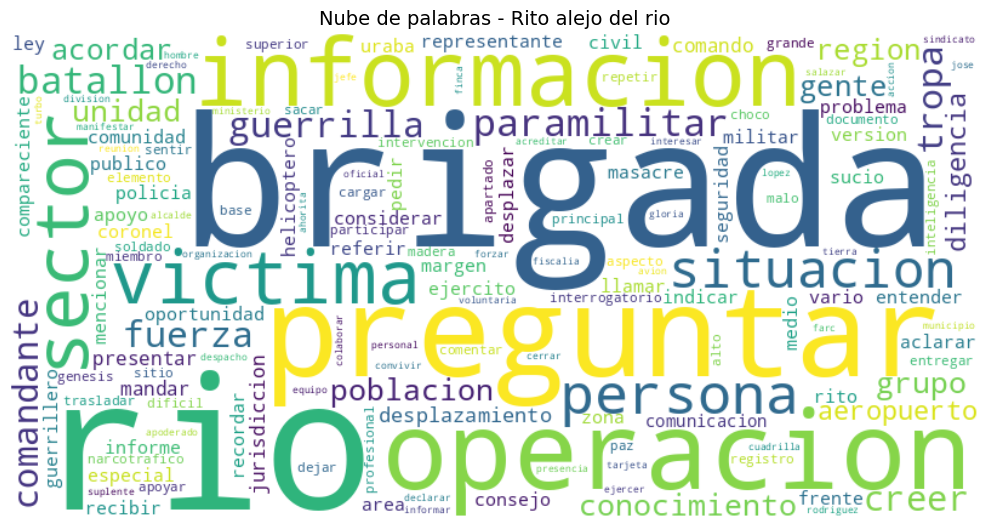

In [12]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()

# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())



                    Texto  Positivo  Negativo   Ira  Anticipación  Disgusto  \
0   Iván Ramirez Quintero      7454      4306  2038          2324       897   
1     Miguel Maza Márquez      3704      2055  1042          1364       503   
2           José Mansilla      2751      1155   497          1123       316   
3  José del Carmen Cuesta      1626       784   465           587       261   
4   Andrés Mario Espinosa      4238      2119   976          1499       601   

   Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0   3944     2046      1850      1006       5915  
1   1684      986       935       607       3104  
2    967      702       601       324       2324  
3    734      335       438       358       1240  
4   1650     1090       893       485       3297  


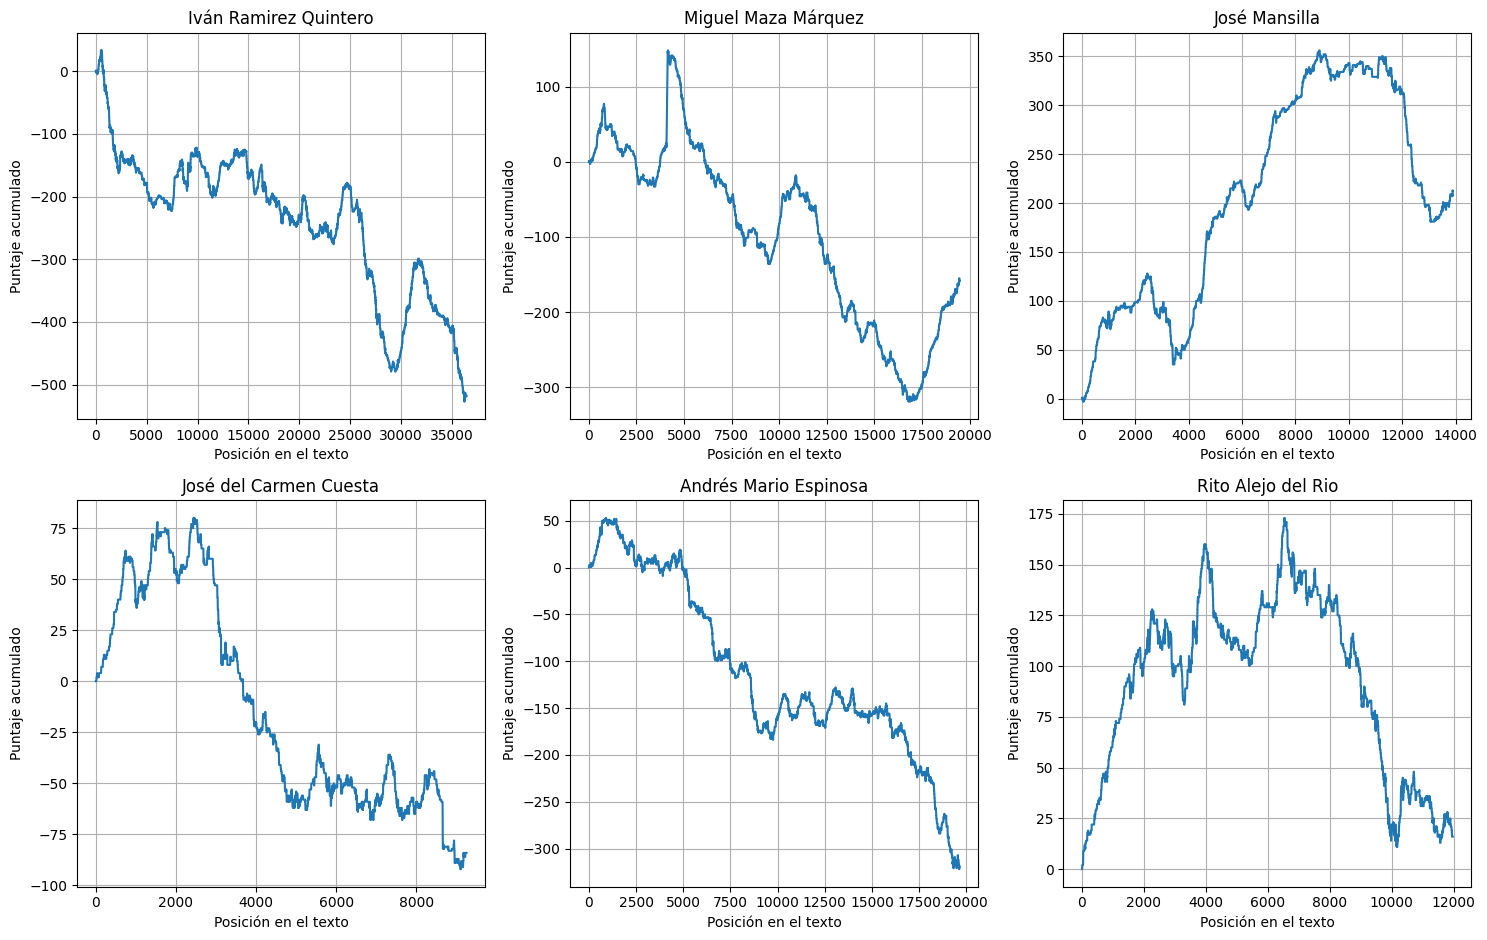

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




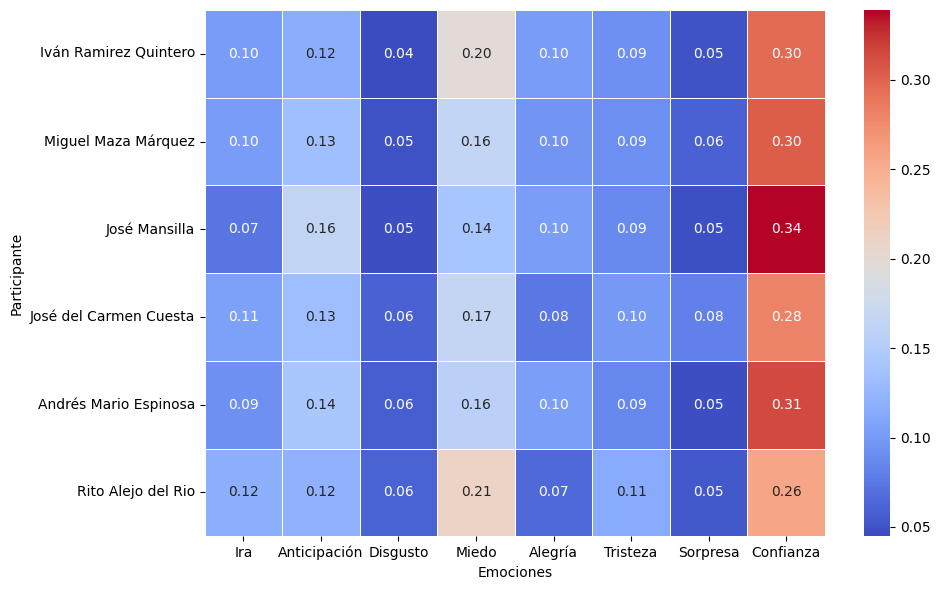

In [26]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Participante')
plt.tight_layout()
plt.show()


# **Identificacion organizaciones**

In [ ]:
# Cargar léxico
ruta_lex = "C:/Users/Desktop/Casos_JEP/material_adicional/lexicon_actors_roles.xlsx"
lexicon = pd.read_excel(ruta_lex)

## Dado que el léxico tiene términos como movimiento 19 de abril - m-19	 es importante buscar por ambos términos debido a que se emplean
## transcripciones: función:
def generar_variantes(nombre):
    nombre = nombre.strip()
    if "-" in nombre:
        parte_larga, sigla = nombre.split("-", 1)
        return {parte_larga.strip().lower(), sigla.strip().lower()}
    return {nombre.lower()}

lexicon["variantes"] = lexicon["Word"].apply(generar_variantes)

# Palabras excluidas (examinadas conforme al contexto y con base en una búsqueda individual para excluirlas)
PALABRAS_EXCLUIDAS = {p.lower() for p in {
    "dos", "uno", "ser", "morena", "uso", "mira", "red", "cric", "mas",
    "hijos", "ado", "usa", "t", "amor", "dac", "pas", "umd", "era", "a",
    "acaba", "sat", "cajar", "activa", "tierra alta-hje29 fm", "98",
    "ccj", "albania", "jac", "ima", "cia", "actor", "ama", "adida",
    "yo puedo", "fjo", "sena", "caj", "tio", "compi", "asf",
    "laguna colorada", "nacional", "la verdad", "el país", "el día", "el tiempo",
    "el mundo", "el frente", "internacional", "el consejo", "la libertad",
    "santa marta", "tierra alta", "la nación", "revista alternativa", "caño jabón",
    "los planes", "la razón", "aldana", "la última", "buenavista", "las delicias",
    "nazaret", "san josé", "la máxima", "la playa", "san juan", "el espacio", "la bonanza",
    "la palma", "las playas", "san francisco", "san luis", "la radio", "el diario",
    "el universal", "la opinión", "fuerza de tarea", "limpios", "gobernaciones",
    "arara", "cabeceras", "el triunfo", "el venado", "la asunción", "la cristalina",
    "la isla", "lame", "las mercedes", "potrerito", "pueblo nuevo",
    "pueblo nuevo - laguna colorada", "san lorenzo", "valdivia", "cristalina", "nuevo horizonte",
    # Departamentos
    "antioquia", "amazonas", "arauca", "atlántico", "bolívar", "boyacá", "caldas",
    "caquetá", "casanare", "cauca", "cesar", "chocó", "córdoba", "cundinamarca",
    "guainía", "guaviare", "huila", "la guajira", "magdalena", "meta", "nariño",
    "norte de santander", "putumayo", "quindío", "risaralda", "san andrés",
    "santander", "sucre", "tolima", "valle del cauca", "vaupés", "vichada"
}}

actor_variantes = {}
for _, row in lexicon.iterrows():
    for v in row["variantes"]:
        actor_variantes.setdefault(row["Word"], set()).add(v.lower())

textos = {
    "andres": texto_andres, "mansilla": texto_mansilla, "cuesta": texto_cuesta,
    "rito": texto_rito, "maza": texto_maza, "ivan": texto_ivan
}

# Encontrar organizaciones en cada texto
def encontrar_organizaciones(texto, actor_variantes, palabras_excluidas):
    texto = texto.lower()
    resultados = {}
    for actor, variantes in actor_variantes.items():
        conteo = sum(
            len(re.findall(r"\b" + re.escape(v) + r"\b", texto))
            for v in variantes if v not in palabras_excluidas
        )
        if conteo > 0:
            resultados[actor] = conteo
    return resultados

# Construir df_orgs
df_orgs = pd.DataFrame([
    {"texto": nombre_texto, "organizacion": org, "frecuencia": freq}
    for nombre_texto, texto in textos.items()
    for org, freq in encontrar_organizaciones(texto, actor_variantes, PALABRAS_EXCLUIDAS).items()
])
df_orgs.sort_values(["texto", "frecuencia"], ascending=[True, False], inplace=True)


lexicon_aux = lexicon[["Word", "Class2"]].copy()
lexicon_aux["Word"] = lexicon_aux["Word"].str.lower()
df_orgs["organizacion"] = df_orgs["organizacion"].str.lower()

df_orgs = (df_orgs
    .merge(lexicon_aux, left_on="organizacion", right_on="Word", how="left")
    .drop(columns=["Word"])
    .loc[lambda df: df["Class2"].str.lower() != "poblaciones"]
)

df_total = (df_orgs
    .groupby(["organizacion", "Class2"], as_index=False)["frecuencia"]
    .sum()
    .sort_values("frecuencia", ascending=False)
)

#### NOTA IMPORTANTE: FARC-EP no está como tal en el texto principalmente se menciona FARC para referirse a las fuerzas armadas revolucionarias de colombia por
#eso se cuentan como grupo militar y no partido politico en el texto dando como resultado una frecuencia de 158.
df_total

,organizacion,Class2,frecuencia
13,departamento administrativo de seguridad - das,ORGANIZACIONES,803
134,grupos paramilitares,ACTORES ARMADOS,190
139,jurisdicción especial para la paz - jep,ESTADO - GOBIERNO,164
145,movimiento 19 de abril - m-19,ACTORES ARMADOS,162
41,partido fuerza alternativa revolucionaria del...,ESTADO - GOBIERNO,156
...,...,...,...
149,oficina del alto comisionado para la paz - oacp,ESTADO - GOBIERNO,1
159,sociedad radio televisión nacional de colombi...,ESTADO - GOBIERNO,1
158,sindicato de trabajadores del agro - sintagro,ORGANIZACIONES,1
161,unidad nacional de protección - unp,ESTADO - GOBIERNO,1


# **Análisis DAS-REDES**

In [19]:
###Hallar las frecuencias de skipgramas filtrados por el DAS y crear las redes egocentradas sobre este nodo:

def contiene_das(nodo):
    return isinstance(nodo, str) and nodo.lower() == "das"

frecuencia_das_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    contador = Counter()
    for (u, v), f in conteo.items():
        if contiene_das(u) or contiene_das(v):
            contador[(u, v)] += f

    frecuencia_das_por_red[nombre] = (
        pd.DataFrame(contador.items(), columns=["skipgrama", "frecuencia"])
        .sort_values("frecuencia", ascending=False)
        .reset_index(drop=True))

subgrafos_das = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]
    G = nx.Graph()
    G.add_edges_from(skipgramas)
    nodos_das = [n for n in G.nodes if contiene_das(n)]
    if not nodos_das:
        continue
    vecinos = set()
    for n in nodos_das:
        vecinos |= set(G.neighbors(n))

    subgrafo = G.subgraph(nodos_das + list(vecinos)).copy()
    subgrafos_das[nombre] = subgrafo


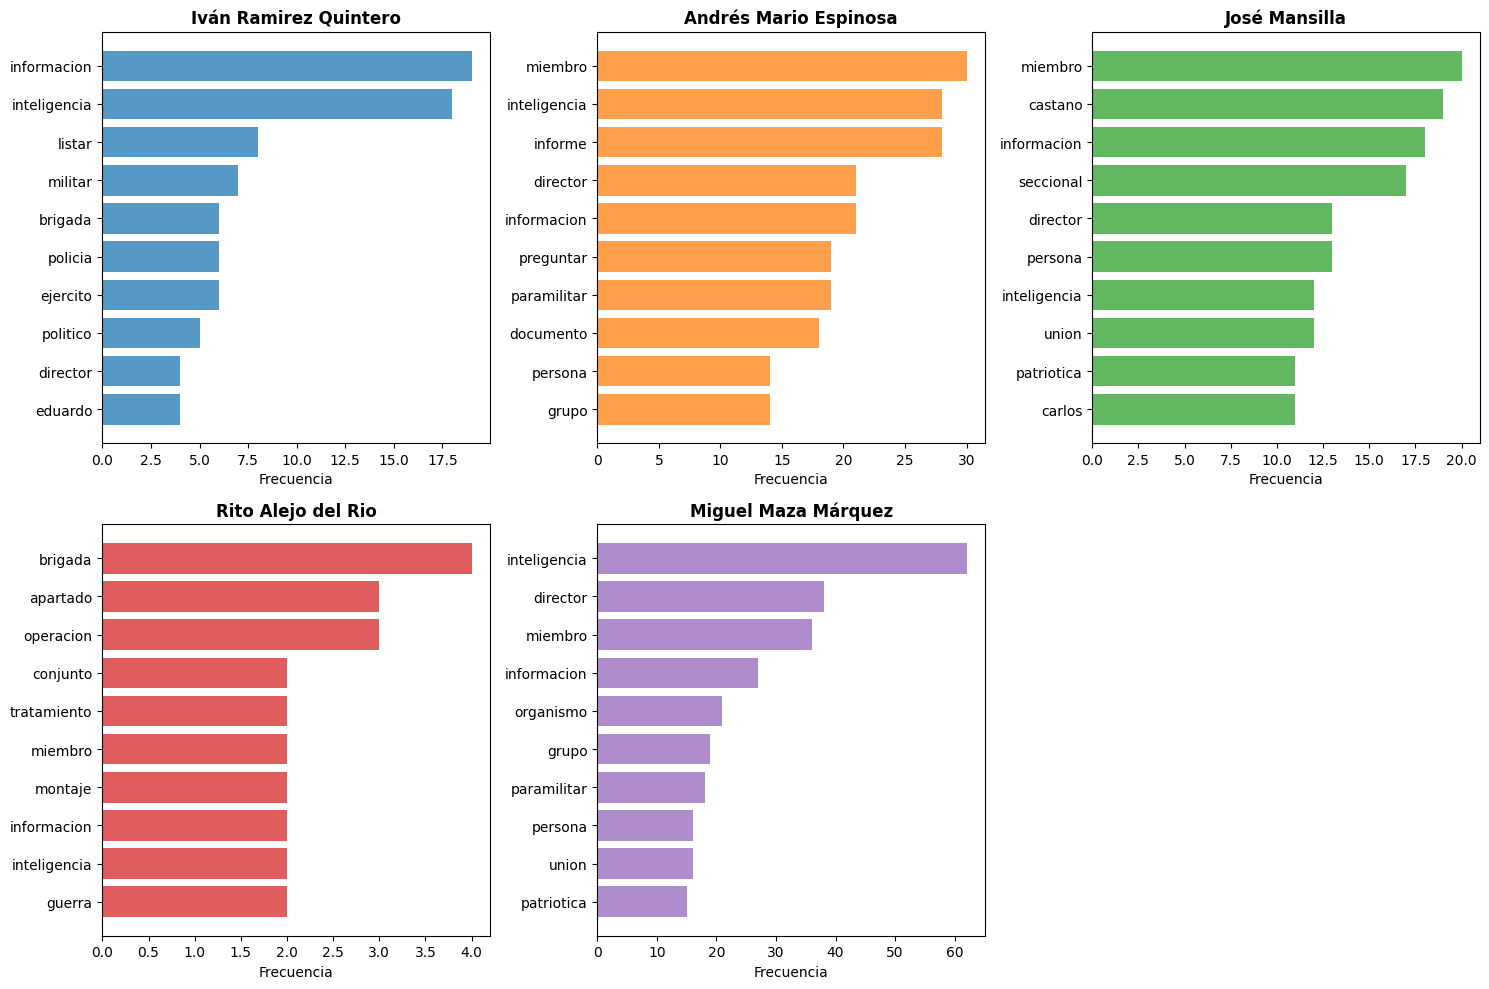

In [20]:
###Graficar los términos con mayor frecuencia  de conexión con el nodo DAS por compareciente/testigo:

def consolidar_skipgramas_no_dirigidos(df):
    df_consolidado = []

    for _, row in df.iterrows():
        palabra1, palabra2 = row['skipgrama']
        par_normalizado = tuple(sorted([palabra1.lower(), palabra2.lower()]))
        df_consolidado.append({
            'skipgrama': par_normalizado,
            'frecuencia': row['frecuencia']})
    df_result = pd.DataFrame(df_consolidado)
    df_result = df_result.groupby('skipgrama', as_index=False)['frecuencia'].sum()
    df_result = df_result.sort_values('frecuencia', ascending=False).reset_index(drop=True)
    return df_result

frecuencia_das_consolidada = {}
for nombre, df in frecuencia_das_por_red.items():
    if df is not None and not df.empty:
        frecuencia_das_consolidada[nombre] = consolidar_skipgramas_no_dirigidos(df)

colores_personas = {"Iván Ramirez Quintero": "#1f77b4", "Andrés Mario Espinosa": "#ff7f0e", "José Mansilla": "#2ca02c",
    "Rito Alejo del Rio": "#d62728","Miguel Maza Márquez": "#9467bd"}

orden = list(colores_personas.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, nombre in enumerate(orden):
    ax = axes[i]
    df = frecuencia_das_consolidada.get(nombre)
    if df is None or df.empty:
        ax.axis("off")
        continue
    top10 = df.head(10).copy()
    top10["palabra"] = top10["skipgrama"].apply(lambda x: x[1] if x[0] == "das" else x[0])
    top10 = top10[::-1]

    ax.barh(y=top10["palabra"],width=top10["frecuencia"],color=colores_personas[nombre],alpha=0.75)
    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    ax.tick_params(axis='y', labelsize=10)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

Iván Ramirez Quintero: nodos=35, aristas=213, densidad=0.358, grado_max=34, transitividad=0.614
Andrés Mario Espinosa: nodos=235, aristas=1681, densidad=0.061, grado_max=234, transitividad=0.210
José Mansilla: nodos=118, aristas=879, densidad=0.127, grado_max=117, transitividad=0.354
Rito Alejo del Rio: nodos=8, aristas=16, densidad=0.571, grado_max=7, transitividad=0.621
Miguel Maza Márquez: nodos=228, aristas=1642, densidad=0.063, grado_max=227, transitividad=0.210


<Figure size 1000x1000 with 0 Axes>

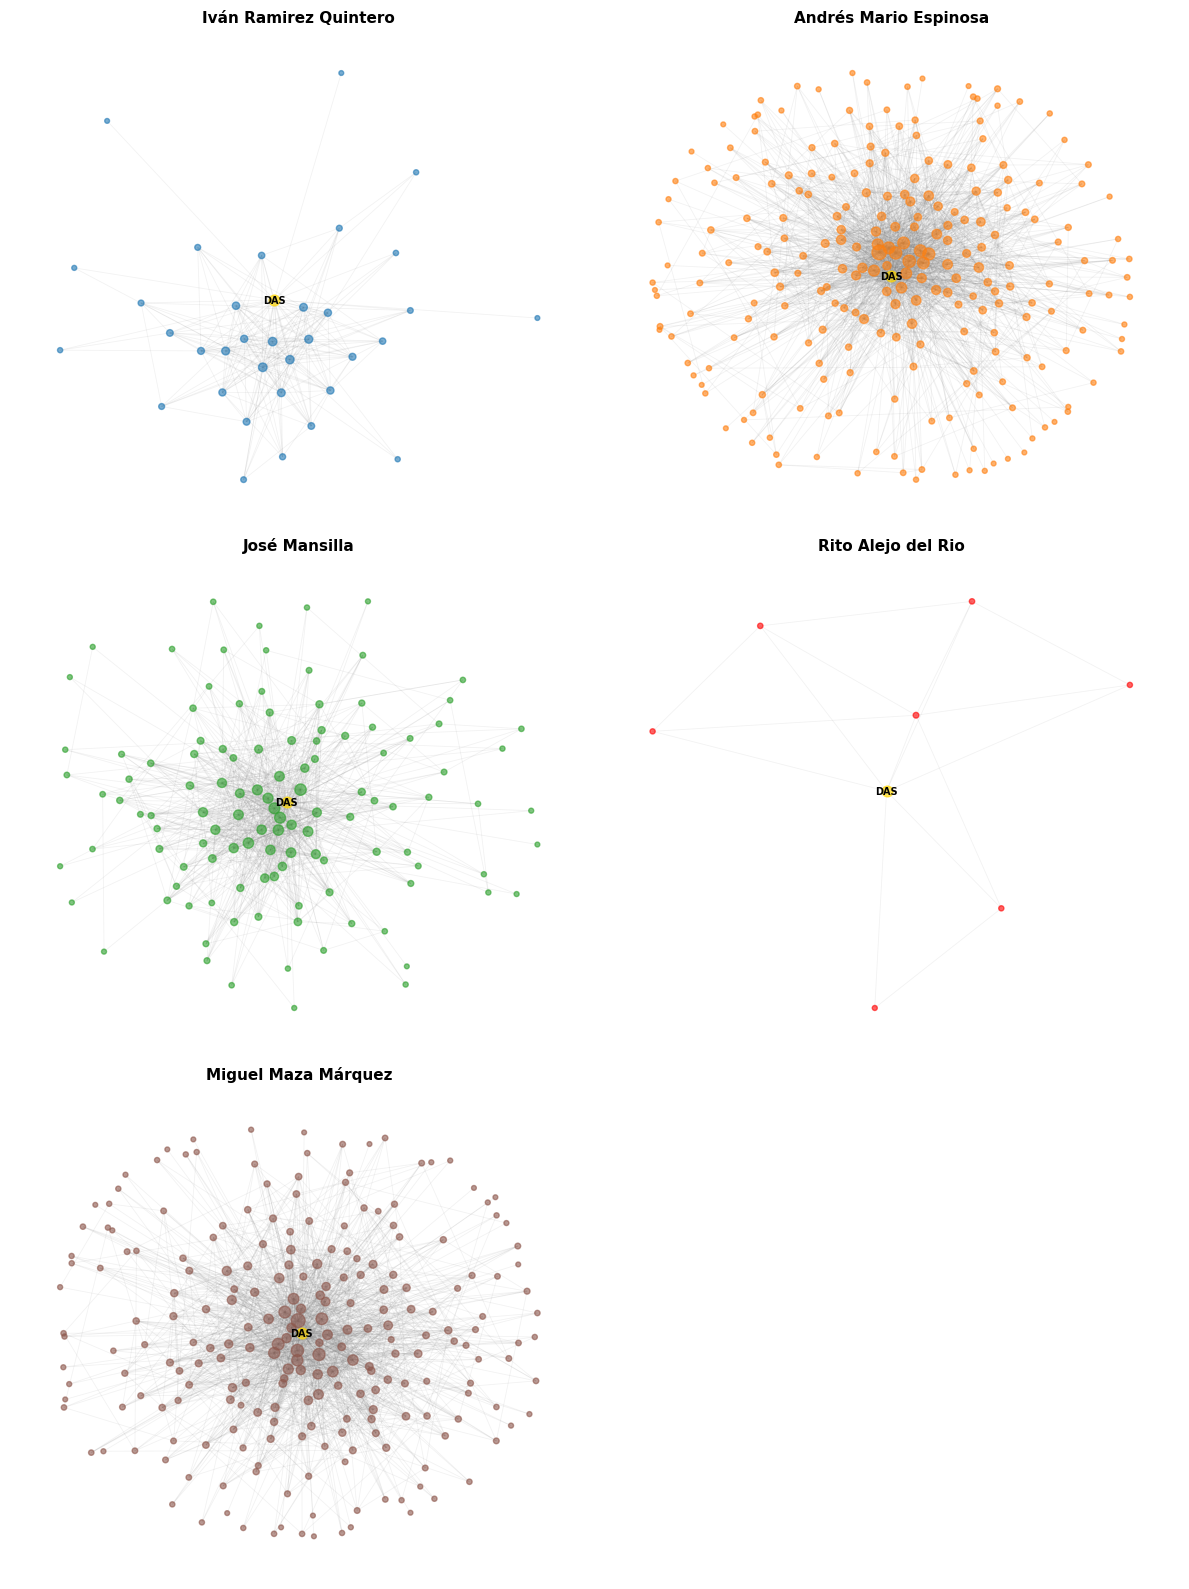

In [21]:

##Redes egocentradas en el nodo DAS:

nombres_personas = {"ivan": "Iván Ramirez Quintero","andres": "Andrés Mario Espinosa","mansilla": "José Mansilla",
    "cuesta": "José del Carmen Cuesta","rito": "Rito Alejo del Rio","maza": "Miguel Maza Márquez"}

colores_personas = {"ivan": "#1f77b4","andres": "#ff7f0e","mansilla": "#2ca02c","cuesta": "#d62728",
    "rito": "red","maza": "#8c564b"}

id_por_nombre = {v: k for k, v in nombres_personas.items()}
plt.figure(figsize=(10, 10))
offsets = {"ivan": np.array([0, 0]),"andres": np.array([3, 0]), "mansilla": np.array([0, 3]),
    "cuesta": np.array([3, 3]), "rito": np.array([1.5, 5]),"maza": np.array([5, 1.5])}
orden = ["ivan", "andres","mansilla", "rito","maza"]

fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for i, key in enumerate(orden):
    ax = axes[i]
    nombre_largo = nombres_personas[key]
    G_sub = subgrafos_das.get(nombre_largo)

    ax.set_title(nombre_largo, fontsize=11, fontweight="bold")
    if G_sub is None or G_sub.number_of_nodes() < 2:
        ax.axis("off")
        continue

    num_nodos = G_sub.number_of_nodes()
    num_aristas = G_sub.number_of_edges()
    densidad = nx.density(G_sub)
    grado_max = max(dict(G_sub.degree()).values())
    transitividad = nx.transitivity(G_sub)
    closeness = nx.closeness_centrality(G_sub)
    betweenness = nx.betweenness_centrality(G_sub, normalized=True)

    print(f"{nombre_largo}: nodos={num_nodos}, aristas={num_aristas}, densidad={densidad:.3f}, grado_max={grado_max}, transitividad={transitividad:.3f}")

    pos = nx.spring_layout(G_sub,seed=42,k=1.2,iterations=80)
    nodos_das = [n for n in G_sub.nodes if contiene_das(n)]
    nodos_otro = [n for n in G_sub.nodes if n not in nodos_das]
    grados = dict(G_sub.degree())
    sizes_otro = [1* grados[n] + 11 for n in nodos_otro]

    nx.draw_networkx_edges(G_sub,pos,ax=ax,edge_color="gray",alpha=0.1,width=0.6)
    nx.draw_networkx_nodes(G_sub,pos,nodelist=nodos_otro,ax=ax,node_size=sizes_otro,node_color=colores_personas[key],alpha=0.6)
    nx.draw_networkx_nodes(G_sub,pos,nodelist=nodos_das,ax=ax,node_size=60,node_color="#FFD700",alpha=0.65)

    labels = {n: "DAS" for n in nodos_das}
    nx.draw_networkx_labels(G_sub,pos,labels=labels,font_size=7,font_weight="bold",ax=ax)
    ax.axis("off")
for j in range(len(orden), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# **RED BASICA**

In [22]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Iván Ramirez Quintero': 2100 nodos, 13670 aristas (componente gigante).
Grafo 'Miguel Maza Márquez': 1443 nodos, 7326 aristas (componente gigante).
Grafo 'José Mansilla': 1129 nodos, 5567 aristas (componente gigante).
Grafo 'José del Carmen Cuesta': 973 nodos, 3546 aristas (componente gigante).
Grafo 'Andrés Mario Espinosa': 1560 nodos, 6811 aristas (componente gigante).
Grafo 'Rito Alejo del Rio': 1065 nodos, 4251 aristas (componente gigante).

Métricas
                        num_nodos  num_aristas  densidad  grado_promedio  \
Iván Ramirez Quintero        2100        13670  0.006203       13.019048   
Miguel Maza Márquez          1443         7326  0.007042       10.153846   
José Mansilla                1129         5567  0.008743        9.861825   
José del Carmen Cuesta        973         3546  0.007499        7.288798   
Andrés Mario Espinosa        1560         6811  0.005601        8.732051   
Rito Alejo del Rio           1065         4251  0.007503        7.983099   

 

In [23]:
top10_grado_por_red

{'Iván Ramirez Quintero':              nodo  grado  porcentaje_grado
 200  inteligencia    379          0.013862
 315       brigada    346          0.012655
 281   informacion    310          0.011339
 157     preguntar    279          0.010205
 234         grupo    266          0.009729
 307    comandante    263          0.009620
 138       persona    240          0.008778
 308      ejercito    227          0.008303
 265   paramilitar    207          0.007571
 65        acordar    198          0.007242,
 'Miguel Maza Márquez':              nodo  grado  porcentaje_grado
 360           das    227          0.015493
 273  inteligencia    159          0.010852
 310         grupo    153          0.010442
 83      preguntar    133          0.009077
 19          union    133          0.009077
 182       persona    125          0.008531
 45        victima    124          0.008463
 20     patriotica    120          0.008190
 306      politico    119          0.008122
 8      diligencia    113  

In [25]:
### Cálculo de centralidad
def max_info(df, col):
    idx = df[col].idxmax()
    return df.loc[idx, col], df.loc[idx, "nodo"]

redes_metrics = {}
centralidades_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    G = nx.Graph()
    G.add_edges_from(datos["skipgramas_filtrados"])

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo":        list(G_gigante.nodes()),
        "grado":       [grados[n]      for n in G_gigante.nodes()],
        "betweenness": [betweenness[n] for n in G_gigante.nodes()],
        "closeness":   [closeness[n]   for n in G_gigante.nodes()],
        "eigenvector": [eigenvector[n] for n in G_gigante.nodes()]
    })
    centralidades_por_red[nombre] = df_centralidad

    grado_max,  nodo_grado_max = max_info(df_centralidad, "grado")
    betw_max,   nodo_betw_max  = max_info(df_centralidad, "betweenness")
    close_max,  nodo_close_max = max_info(df_centralidad, "closeness")
    eig_max,    nodo_eig_max   = max_info(df_centralidad, "eigenvector")

    redes_metrics[nombre] = {
        "num_nodos":             num_nodos,
        "grado_max":             grado_max,       "nodo_grado_max":       nodo_grado_max,
        "betweenness_max":       betw_max,         "nodo_betweenness_max": nodo_betw_max,
        "closeness_max":         close_max,        "nodo_closeness_max":   nodo_close_max,
        "eigenvector_max":       eig_max,          "nodo_eigenvector_max": nodo_eig_max,
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print(df_metrics)

Grafo 'Iván Ramirez Quintero': 2100 nodos, 13670 aristas (componente gigante).
Grafo 'Miguel Maza Márquez': 1443 nodos, 7326 aristas (componente gigante).
Grafo 'José Mansilla': 1129 nodos, 5567 aristas (componente gigante).
Grafo 'José del Carmen Cuesta': 973 nodos, 3546 aristas (componente gigante).
Grafo 'Andrés Mario Espinosa': 1560 nodos, 6811 aristas (componente gigante).
Grafo 'Rito Alejo del Rio': 1065 nodos, 4251 aristas (componente gigante).
                        num_nodos  grado_max nodo_grado_max  betweenness_max  \
Iván Ramirez Quintero        2100        379   inteligencia         0.095498   
Miguel Maza Márquez          1443        227            das         0.131882   
José Mansilla                1129        180      preguntar         0.115642   
José del Carmen Cuesta        973        139         garzon         0.152465   
Andrés Mario Espinosa        1560        249   inteligencia         0.134319   
Rito Alejo del Rio           1065        141        brigada     